<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **Collecting Job Data Using APIs**


Estimated time needed: **30** minutes


## Objectives


After completing this lab, you will be able to:


*   Collect job data using Jobs API
*   Store the collected data into an excel spreadsheet.


><strong>Note: Before starting with the assignment make sure to read all the instructions and then move ahead with the coding part.</strong>


#### Instructions


To run the actual lab, firstly you need to click on the [Jobs_API](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DA0321EN-SkillsNetwork/labs/module%201/Accessing%20Data%20Using%20APIs/Jobs_API.ipynb) notebook link. The file contains flask code which is required to run the Jobs API data.

Now, to run the code in the file that opens up follow the below steps.

Step1: Download the file. 

Step2: Upload the file into your current Jupyter environment using the upload button in your Jupyter interface. Ensure that the file is in the same folder as your working .ipynb file.

Step 2: If working in a local Jupyter environment, use the "Upload" button in your Jupyter interface to upload the Jobs_API notebook into the same folder as your current .ipynb file.

<img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DA0321EN-SkillsNetwork/labs/module%201/Accessing%20Data%20Using%20APIs/Upload.PNG">

Step3:  Open the Jobs_API notebook, and run all the cells to start the Flask application. Once the server is running, you can access the API from the URL provided in the notebook.

If you want to learn more about flask, which is optional, you can click on this link [here](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DA0321EN-SkillsNetwork/labs/module%201/Accessing%20Data%20Using%20APIs/FLASK_API.md.html).

Once you run the flask code, you can start with your assignment.


## Dataset Used in this Assignment

The dataset used in this lab comes from the following source: https://www.kaggle.com/promptcloud/jobs-on-naukricom under the under a **Public Domain license**.

> Note: We are using a modified subset of that dataset for the lab, so to follow the lab instructions successfully please use the dataset provided with the lab, rather than the dataset from the original source.

The original dataset is a csv. We have converted the csv to json as per the requirement of the lab.


## Warm-Up Exercise


Before you attempt the actual lab, here is a fully solved warmup exercise that will help you to learn how to access an API.


Using an API, let us find out who currently are on the International Space Station (ISS).<br> The API at [http://api.open-notify.org/astros.json](http://api.open-notify.org/astros.json?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDA0321ENSkillsNetwork21426264-2021-01-01&cm_mmc=Email_Newsletter-_-Developer_Ed%2BTech-_-WW_WW-_-SkillsNetwork-Courses-IBM-DA0321EN-SkillsNetwork-21426264&cm_mmca1=000026UJ&cm_mmca2=10006555&cm_mmca3=M12345678&cvosrc=email.Newsletter.M12345678&cvo_campaign=000026UJ) gives us the information of astronauts currently on ISS in json format.<br>
You can read more about this API at [http://open-notify.org/Open-Notify-API/People-In-Space/](http://open-notify.org/Open-Notify-API/People-In-Space?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDA0321ENSkillsNetwork21426264-2021-01-01&cm_mmc=Email_Newsletter-_-Developer_Ed%2BTech-_-WW_WW-_-SkillsNetwork-Courses-IBM-DA0321EN-SkillsNetwork-21426264&cm_mmca1=000026UJ&cm_mmca2=10006555&cm_mmca3=M12345678&cvosrc=email.Newsletter.M12345678&cvo_campaign=000026UJ)


In [1]:
import requests # you need this module to make an API call
import pandas as pd

In [2]:
api_url = "http://api.open-notify.org/astros.json" # this url gives use the astronaut data

In [4]:
response = requests.get(api_url) # Call the API using the get method and store the
                                # output of the API call in a variable called response.

In [6]:
if response.ok:             # if all is well() no errors, no network timeouts)
    data = response.json()  # store the result in json format in a variable called data
                            # the variable data is of type dictionary.

In [8]:
print(data)   # print the data just to check the output or for debugging

{'people': [{'craft': 'ISS', 'name': 'Oleg Kononenko'}, {'craft': 'ISS', 'name': 'Nikolai Chub'}, {'craft': 'ISS', 'name': 'Tracy Caldwell Dyson'}, {'craft': 'ISS', 'name': 'Matthew Dominick'}, {'craft': 'ISS', 'name': 'Michael Barratt'}, {'craft': 'ISS', 'name': 'Jeanette Epps'}, {'craft': 'ISS', 'name': 'Alexander Grebenkin'}, {'craft': 'ISS', 'name': 'Butch Wilmore'}, {'craft': 'ISS', 'name': 'Sunita Williams'}, {'craft': 'Tiangong', 'name': 'Li Guangsu'}, {'craft': 'Tiangong', 'name': 'Li Cong'}, {'craft': 'Tiangong', 'name': 'Ye Guangfu'}], 'number': 12, 'message': 'success'}


Print the number of astronauts currently on ISS.


In [9]:
print(data.get('number'))

12


Print the names of the astronauts currently on ISS.


In [10]:
astronauts = data.get('people')
print("There are {} astronauts on ISS".format(len(astronauts)))
print("And their names are :")
for astronaut in astronauts:
    print(astronaut.get('name'))

There are 12 astronauts on ISS
And their names are :
Oleg Kononenko
Nikolai Chub
Tracy Caldwell Dyson
Matthew Dominick
Michael Barratt
Jeanette Epps
Alexander Grebenkin
Butch Wilmore
Sunita Williams
Li Guangsu
Li Cong
Ye Guangfu


Hope the warmup was helpful. Good luck with your next lab!


## Lab: Collect Jobs Data using Jobs API


### Objective: Determine the number of jobs currently open for various technologies  and for various locations


Collect the number of job postings for the following locations using the API:

* Los Angeles
* New York
* San Francisco
* Washington DC
* Seattle
* Austin
* Detroit


In [11]:
#Import required libraries
import pandas as pd
import json


#### Write a function to get the number of jobs for the Python technology.
> **Note:** 
While completing this exercise, first retrieve the full dataset from the API endpoint.  
After retrieving the data, apply the required filtering and calculations locally in Python based on the given parameters.
  
 ##### The keys in the json are 
 * Job Title
 
 * Job Experience Required
 
 * Key Skills
 
 * Role Category
 
 * Location
 
 * Functional Area
 
 * Industry
 
 * Role 
 
You can also view  the json file contents  from the following URL.

https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DA0321EN-SkillsNetwork/labs/module%201/Accessing%20Data%20Using%20APIs/jobs.json



In [14]:
api_url="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DA0321EN-SkillsNetwork/labs/module%201/Accessing%20Data%20Using%20APIs/jobs.json"

In [49]:


def get_number_of_jobs_T(technology):
    number_of_jobs = 0
    response = requests.get(api_url)
    if response.ok:
        jobs_data = response.json()
        for job in jobs_data:
            if technology.lower() in job.get('Key Skills', '').lower():
                number_of_jobs += 1
    else:
        print(f"Error: Unable to retrieve data. Status code: {response.status_code}")

    return technology,number_of_jobs


Calling the function for Python and checking if it works.


In [50]:
get_number_of_jobs_T("Python")

('Python', 1173)

#### Write a function to find number of jobs in US for a location of your choice


In [15]:
 def get_number_of_jobs_L(location):
    number_of_jobs = 0
    response = requests.get(api_url)
    
    if response.ok:
        L_data = response.json()
       
        for job in L_data:
            if location.lower() in job.get('Location', '').lower():
                number_of_jobs += 1
    else:
        print(f"Error: Unable to retrieve data. Status code: {response.status_code}")

    return location,number_of_jobs


Call the function for Los Angeles and check if it is working.


In [16]:
#your code goes here
get_number_of_jobs_L("Austin")

('Austin', 434)

### Store the results in an excel file


Call the API for all the given locations above and write the results in an excel spreadsheet


If you do not know how create excel file using python, double click here for **hints**.

<!--

from openpyxl import Workbook        # import Workbook class from module openpyxl
wb=Workbook()                        # create a workbook object
ws=wb.active                         # use the active worksheet
ws.append(['Country','Continent'])   # add a row with two columns 'Country' and 'Continent'
ws.append(['Eygpt','Africa'])        # add a row with two columns 'Egypt' and 'Africa'
ws.append(['India','Asia'])          # add another row
ws.append(['France','Europe'])       # add another row
wb.save("countries.xlsx")            # save the workbook into a file called countries.xlsx


-->


Create a python list of all locations for which you need to find the number of jobs postings.


In [17]:
locations=['Los Angeles', 'New York', 'San Francisco', 'Washington DC', 'Seattle', 'Austin', 'Detroit']
print(locations)

['Los Angeles', 'New York', 'San Francisco', 'Washington DC', 'Seattle', 'Austin', 'Detroit']


Import libraries required to create excel spreadsheet


In [18]:
# your code goes here
%pip install openpyxl
from openpyxl import Workbook

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.3/251.3 kB 14.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


Create a workbook and select the active worksheet


In [19]:
# your code goes here
wb = Workbook()
ws = wb.active
ws.append(['Location', 'Number of Job Postings'])

Find the number of jobs postings for each of the location in the above list.
Write the location name and the number of jobs postings into the excel spreadsheet.


In [20]:
for city in locations:
    try:
        response = requests.get(api_url) # Using your lab's api_url variable
        if response.status_code == 200:
            data = response.json()
            
            # Count only items where "Location" matches the current city in loop
            count = 0
            for job in data:
                if job.get("Location") == city:
                    count += 1
            job_count = count
        else:
            job_count = 0
    except Exception as e:
        print(f"Error for {city}: {e}")
        job_count = 0
    
    # Append to the sheet
    ws.append([city, job_count])
    print(f"Recorded: {city:15} | Count: {job_count}")

Recorded: Los Angeles     | Count: 640
Recorded: New York        | Count: 3226
Recorded: San Francisco   | Count: 435
Recorded: Washington DC   | Count: 5316
Recorded: Seattle         | Count: 3375
Recorded: Austin          | Count: 434
Recorded: Detroit         | Count: 3945


Save into an excel spreadsheet named **job-postings.xlsx**.


In [21]:
#your code goes here
wb.save("job-postings.xslx")
print(f"\nSuccess! File saved as job-postings.xlsx")


Success! File saved as job-postings.xlsx


In [22]:
import pandas as pd

# Load the file you saved
df = pd.read_excel('job-postings.xlsx')

# Option 1: Display the whole table (standard Jupyter formatting)
df

,Location,number of job posting
0,Los Angeles,640
1,New York,3226
2,San Francisco,435
3,Washington DC,5316
4,Seattle,3375
5,Austin,434
6,Detroit,3945
7,Technology,number of job posting
8,C,25114
9,C#,526


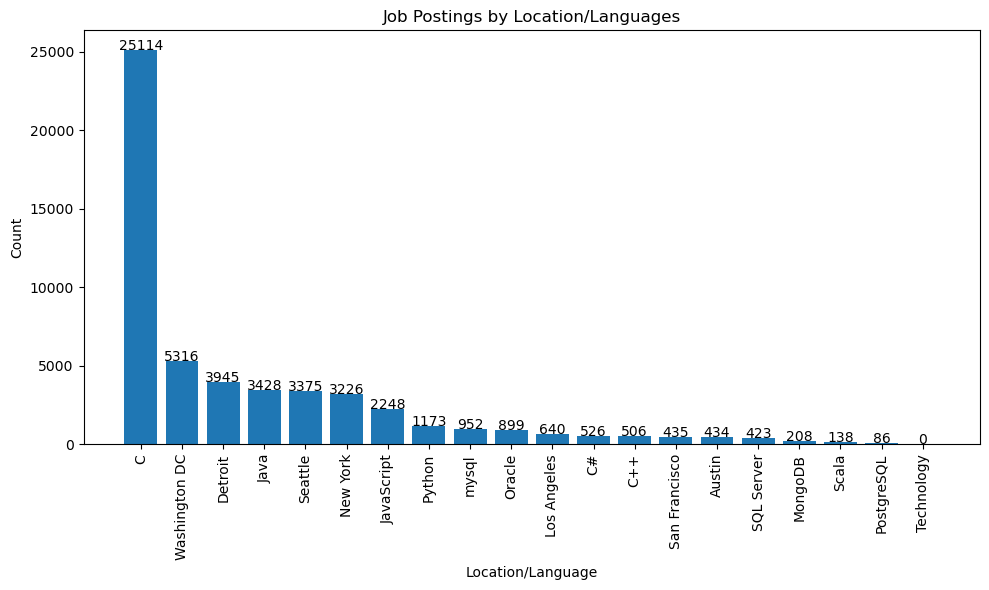

         Location  number of job posting
8               C                  25114
3   Washington DC                   5316
6         Detroit                   3945
11           Java                   3428
4         Seattle                   3375
1        New York                   3226
12     JavaScript                   2248
13         Python                   1173
17          mysql                    952
15         Oracle                    899
0     Los Angeles                    640
9              C#                    526
10            C++                    506
2   San Francisco                    435
5          Austin                    434
16     SQL Server                    423
19        MongoDB                    208
14          Scala                    138
18     PostgreSQL                     86
7      Technology                      0


In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import ast

# 1. Load the file
df = pd.read_excel('job-postings.xlsx')

# 2. Define your column names correctly (using underscores)
location_col = 'Location'
count_col = 'number of job posting' # This matches the header string in Excel

# 3. Clean the data 
# This handles those {'Job Postings': '440'} strings in your cells
def clean_job_count(val):
    try:
        if isinstance(val, str) and '{' in val:
            # Convert string representation of dict to actual dict
            d = ast.literal_eval(val)
            # Extract the value and turn it into an integer
            return int(d.get('Job Postings', 0))
        return int(float(val)) # Handle normal numbers or strings like "440"
    except:
        return 0

# Apply the cleaning to your count column
df[count_col] = df[count_col].apply(clean_job_count)

# 4. Sort Descending
df_sorted = df.sort_values(by=count_col, ascending=False)

# 5. Create the Bar Chart
plt.figure(figsize=(10, 6))
plt.bar(df_sorted[location_col], df_sorted[count_col])

plt.title('Job Postings by Location/Languages')
plt.xlabel('Location/Language')
plt.ylabel('Count')
plt.xticks(rotation=90)

# Add numeric labels on top of bars
for i, v in enumerate(df_sorted[count_col]):
    plt.text(i, v + 2, str(v), ha='center')

plt.tight_layout()
plt.show()

# Print the final table to verify
print(df_sorted)

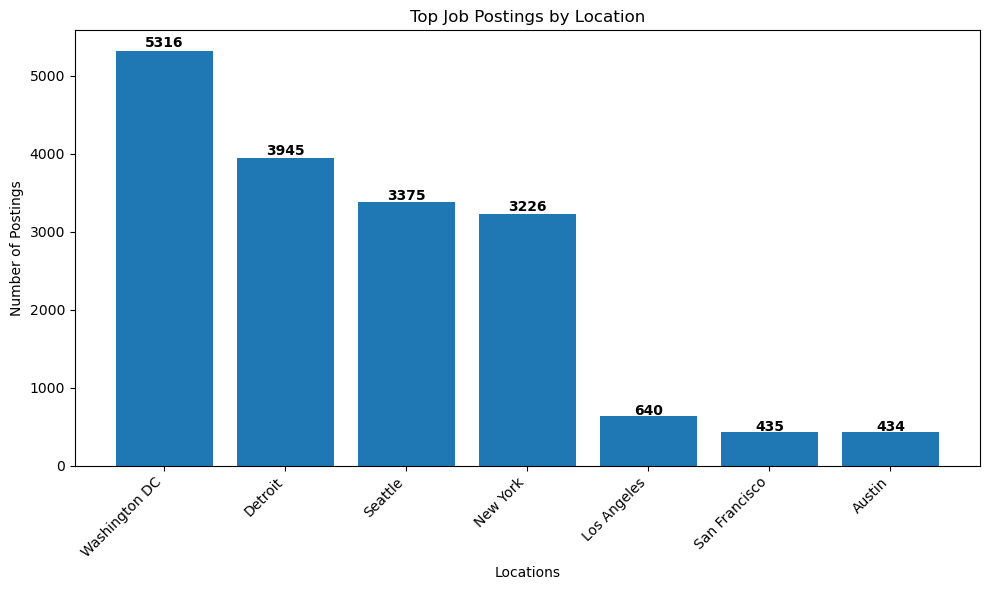

,Location,number of job posting
3,Washington DC,5316
6,Detroit,3945
4,Seattle,3375
1,New York,3226
0,Los Angeles,640
2,San Francisco,435
5,Austin,434


In [38]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_excel('job-postings.xlsx')

# Slice the data to get only index 0 to 6
# .iloc[0:7] takes the first 7 rows
df_subset = df.iloc[0:7].copy()

count_column = df_subset.columns[1] # Automatically selects the 2nd column
df_sorted = df_subset.sort_values(by=count_column, ascending=False)

# Bar Chart
plt.figure(figsize=(10, 6))
plt.bar(df_sorted.iloc[:, 0], df_sorted.iloc[:, 1])

# Formatting
plt.title('Top Job Postings by Location')
plt.xlabel('Locations')
plt.ylabel('Number of Postings')
plt.xticks(rotation=45, ha='right')

# Add value labels on top of each bar
for i, v in enumerate(df_sorted.iloc[:, 1]):
    plt.text(i, v + (v * 0.01), str(int(v)), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Display the sorted data for verification
df_sorted

#### In the similar way, you can try for below given key skills and results  can be stored in an excel sheet.


Collect the number of job postings for the following key skills using the API:

*   C
*   C#
*   C++
*   Java
*   JavaScript
*   Python
*   Scala
*   Oracle
*   SQL Server
*   MySQL Server
*   PostgreSQL
*   MongoDB


In [36]:
# your code goes here
import requests
from openpyxl import Workbook

# 1. Reset Excel
wb = Workbook()
ws = wb.active
ws.append(['Technology', 'Number of Job Postings'])

# 2. Get the full data once (to be efficient)
response = requests.get(api_url)
if response.status_code == 200:
    full_data = response.json()
    print(f"Total jobs to search through: {len(full_data)}")
else:
    full_data = []
    print("Failed to fetch data")

# 3. Technologies to count
technologies = ['C', 'C#', 'C++', 'Java', 'JavaScript', 'Python', 'Scala', 'Oracle', 'SQL Server', 'MySQL Server', 'PostgreSQL', 'MongoDB']

# 4. Count each tech manually
for tech in technologies:
    count = 0
    for job in full_data:
        # Check 'Key Skills' (or whatever column your API uses)
        # We use .lower() to make sure "python" matches "Python"
        skills = str(job.get('Key Skills', '')).lower()
        
        # We use word boundaries or specific checks to avoid 'C' matching 'C++'
        if tech.lower() in skills:
            count += 1
            
    # Append tech to Column A, and count to Column B
    ws.append([tech, count])
    print(f"Technology: {tech:12} | Count: {count}")

# 5. Save
wb.save("job-postings-tech.xlsx")

Total jobs to search through: 27005
Technology: C            | Count: 25114
Technology: C#           | Count: 526
Technology: C++          | Count: 506
Technology: Java         | Count: 3428
Technology: JavaScript   | Count: 2248
Technology: Python       | Count: 1173
Technology: Scala        | Count: 138
Technology: Oracle       | Count: 899
Technology: SQL Server   | Count: 423
Technology: MySQL Server | Count: 0
Technology: PostgreSQL   | Count: 86
Technology: MongoDB      | Count: 208


## Authors


Ayushi Jain


### Other Contributors


Rav Ahuja

Lakshmi Holla

Malika


Copyright © IBM Corporation.


<!--## Change Log


<!--| Date (YYYY-MM-DD) | Version | Changed By        | Change Description                 |
| ----------------- | ------- | ----------------- | ---------------------------------- | 
| 2022-01-19        | 0.3     | Lakshmi Holla        | Added changes in the markdown      |
| 2021-06-25        | 0.2     | Malika            | Updated GitHub job json link       |
| 2020-10-17        | 0.1     | Ramesh Sannareddy | Created initial version of the lab |--!>
